RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
CustomerId — идентификатор клиента
Surname — фамилия клиента
CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
Geography — страна клиента (банк международный)
Gender — пол клиента
Age — возраст клиента
Tenure — сколько лет клиент пользуется услугами банка
Balance — баланс на счетах клиента в банке
NumOfProducts — количество услуг банка, которые приобрёл клиент
HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
EstimatedSalary — предполагаемая заработная плата клиента
Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop(['RowNumber'],axis=1)
churn_data['Status'] = churn_data.Exited.map({0: 'Лояльный клиент', 1: 'Ушедший клиент'})
churn_data.IsActiveMember = churn_data.IsActiveMember.map({0: 'Активный клиент', 1: 'Неактивный клиент'})
churn_data.info()
churn_data.head()
churn_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  object 
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
 13  Status           10000 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,199992.480000,1.000000


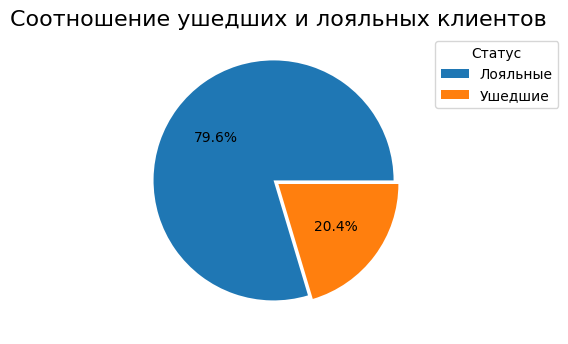

In [2]:
#9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

fig = plt.figure(figsize=(6, 3))
ax = fig.add_axes((1, 1, 1, 1))
pie = ax.pie(churn_data['Status'].value_counts(), autopct='%1.1f%%', explode = [0.05, 0])
title = ax.set_title('Соотношение ушедших и лояльных клиентов', fontsize=16)
legend = ax.legend(labels=('Лояльные', 'Ушедшие'),
          title="Статус",
          loc="upper left",
          bbox_to_anchor=(1, 0, 0.5, 1))

#Выводы: Большинство клиентов - лояльные, ушедших клиентов всего 1/5 от общего количества

In [3]:
#9.2. Постройте график, показывающий распределение баланса пользователей,
# у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

fig = px.histogram(churn_data[churn_data['Balance']>=2500],
             x = 'Balance', # количественный признак
             nbins=40,
             #color = 'Status', # категориальный признак
             marginal = 'box', # дополнительный график: boxplot
)
fig.update_layout(
title_text = 'Распределение размера баланса по всем клиентам',
    xaxis_title_text='Баланс клиентов',
    yaxis_title_text='Количество клиентов'
)
fig.show()

#Распределение нормальное:большинство наблюдений сосредоточено около средних значений, а именно в промежутке от 100 до 150 тысяч. 
#Выбросы в промежутках 2500-41000 и 199000-250000 незначительны по количеству.

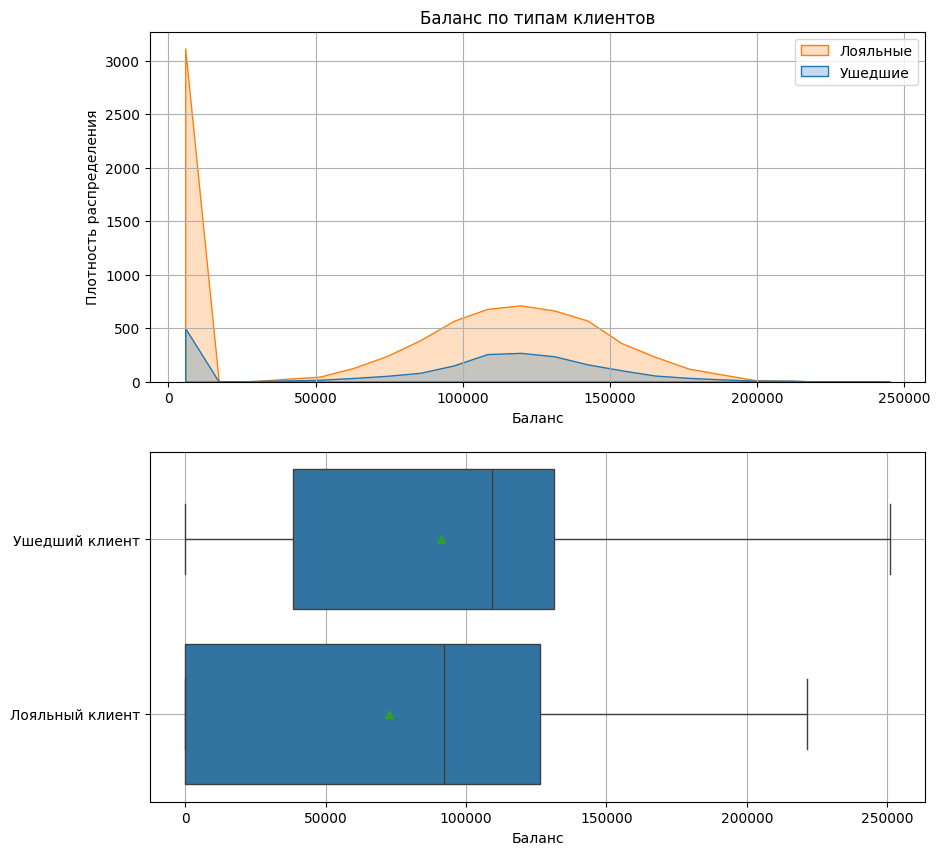

In [4]:
#9.3.Посмотрите на распределение баланса клиента в разрезе признака оттока.
# Как различаются суммы на накопительном счёте ушедших и лояльных клиентов?
# Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
plot1=sns.histplot(
    churn_data,
    x='Balance',
    hue='Status',
    element="poly",
    ax = axes[0]
)
plot1.set_title('Баланс по типам клиентов')
plot1.set_ylabel('Плотность распределения')
plot1.set_xlabel('Баланс')
plot1.legend(['Лояльные', 'Ушедшие'])
plot1.grid()

plot2=sns.boxplot(
    churn_data,
    x='Balance',
    y='Status',
    ax = axes[1],
    showmeans=True
)
plot2.set_ylabel('')
plot2.set_xlabel('Баланс')
plot2.grid()

# Выводы: Лояльных клиентов с нулевым балансом больше, чем ушедших. У ушедших же клиентов выше медианное значение, 
# и длиннее правый хвост, а значит среди них больше клиентов с большей суммой на балансе. Такие клиенты предпочитают другой банк.

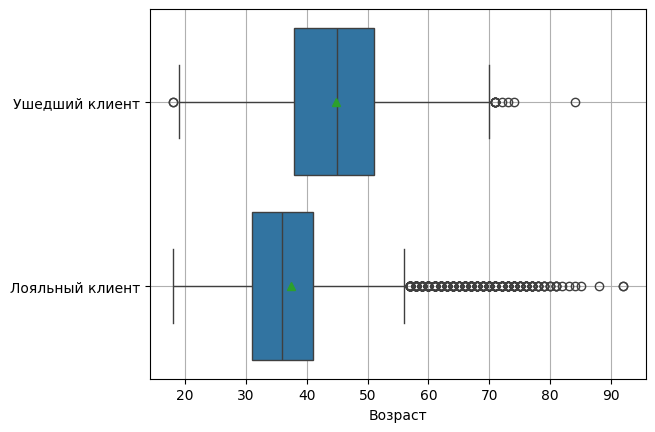

In [5]:
#9.4. Посмотрите на распределение возраста в разрезе признака оттока. 
# В какой группе больше потенциальных выбросов? 
# На какую возрастную категорию клиентов стоит обратить внимание банку?

plot3=sns.boxplot(
    churn_data,
    x='Age',
    y='Status',
    showmeans=True
)
plot3.set_ylabel('')
plot3.set_xlabel('Возраст')
plot3.grid()

#Выводы: Потенциальных выбросов больше в группе лояльных клиентов. Средний возраст лояльных клиентов ниже, чем у ушедших.
# Обратить внимание стоит на клиентов в возрасте 39-51 год, так как они более подвержены уходу из банка. 
     

Text(0, 0.5, 'Кредитный рейтинг')

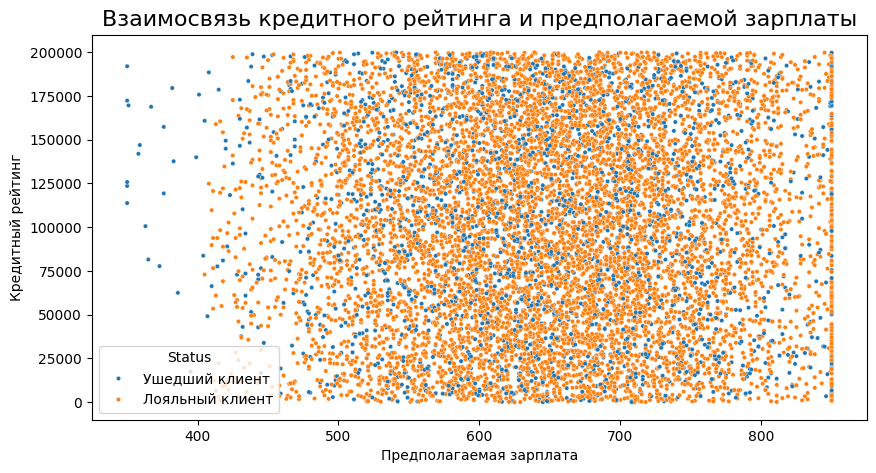

In [6]:
#9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. 
#Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

fig = plt.figure(figsize=(10, 5))

scatterplot = sns.scatterplot(
    data=churn_data,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Status',
    s=10
)
scatterplot.set_title('Взаимосвязь кредитного рейтинга и предполагаемой зарплаты', fontsize=16)
scatterplot.set_xlabel('Предполагаемая зарплата')
scatterplot.set_ylabel('Кредитный рейтинг')

#Выводы: Явной взаимосвязи не обнаружено

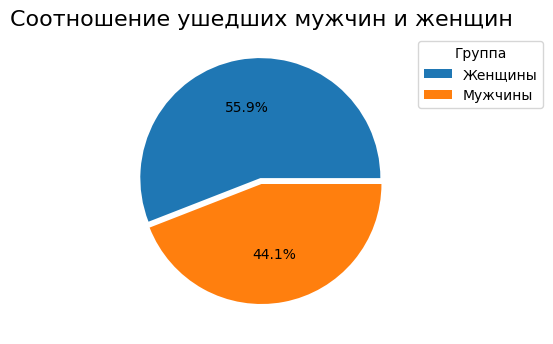

In [7]:
#9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

fig = plt.figure(figsize=(6, 3))
ax = fig.add_axes((1, 1, 1, 1))
pie = ax.pie(churn_data[churn_data['Status'] == 'Ушедший клиент'].groupby('Gender')['Status'].value_counts(), 
             autopct='%1.1f%%',
             explode = [0.05, 0])
title = ax.set_title('Соотношение ушедших мужчин и женщин', fontsize=16)
legend = ax.legend(labels=('Женщины', 'Мужчины'),
          title="Группа",
          loc="upper left",
          bbox_to_anchor=(1, 0, 0.5, 1))

#Выводы: Женщины уходят чаще мужчин

In [8]:
#9.7. Как отток клиентов зависит от числа приобретённых у банка услуг?
# Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.
fig = px.histogram(churn_data, 
                   x='NumOfProducts', 
                   histnorm='percent',
                   text_auto=True,
                   color ='Status',
                   )
fig.update_layout(bargap=0.1)

fig.update_layout(
    title_text='Зависимость оттока клиентов от количества приобритенных продуктов',
    yaxis_title_text='Доля'
 )

#Выводы: Большая часть, почти 70%, ушедших клиентов останавливались на 1 продукте банка.
# Для лояльных клиентов характерно иметь 2 (50%) или 1 (46%) продукт, больше 2-х продуктов брали зачастую только ушедшие клиенты.

In [9]:
#9.8. Как влияет наличие статуса активного клиента на отток клиентов? 
#Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=["Неактивные клиенты", "Активные клиенты"], 
                    values=churn_data[churn_data.Status =="Ушедший клиент"]['IsActiveMember'].value_counts(),
                    name="Ушедшие"), 1, 1)
fig.add_trace(go.Pie(labels=["Активные клиенты", "Неактивные клиенты"],
                    values=churn_data[churn_data.Status =="Лояльный клиент"]['IsActiveMember'].value_counts(),
                    name="Лояльные"), 1, 2)

# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.5, hoverinfo="label+percent+name")

fig.update_layout(
    title_text="Влияние статуса активного клиента на отток клиентов",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Ушедшие', x=sum(fig.get_subplot(1, 1).x) / 2, y=0.5,
                      font_size=20, showarrow=False, xanchor="center"),
                 dict(text='Лояльные', x=sum(fig.get_subplot(1, 2).x) / 2, y=0.5,
                      font_size=20, showarrow=False, xanchor="center")])
fig.show()

#Выводы:
# Уходу из банка более подвержены клиенты со статусом Неактивный. 
# Для Лояльных клиентов показатель активных клиентов = 55.5%, в то время как у Ушедших процент активных клиентов всего 36,1%.
# Рекомендация банку: повышать активность клиентов, больше выгодных предложений и акций.

In [10]:
#9.9. В какой стране доля ушедших клиентов больше? 
#Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

df = pd.DataFrame(dict(churn_data[churn_data.Status == 'Ушедший клиент'].Geography.value_counts()*100/churn_data.Geography.value_counts()).items(), 
                  columns=['Country', 'StatusSum'])

fig = px.choropleth(
    data_frame=df, 
    locations="Country", 
    locationmode = "country names",
    color="StatusSum", 
    color_continuous_scale="Aggrnyl",
    range_color=[0, 35],
    title='Доля ушедших клиентов по странам',
    width=800,
    height=500,
    scope = 'europe'
)
fig.show()

#Выводы: В Германии доля ушедщих клиентов самая большая, в сравнении с другими странами показатель больше в 2 раза. 
# Так, для Германии доля ушедших клиентов 32,4%, а для Франции и Испании в районе 16-17%.

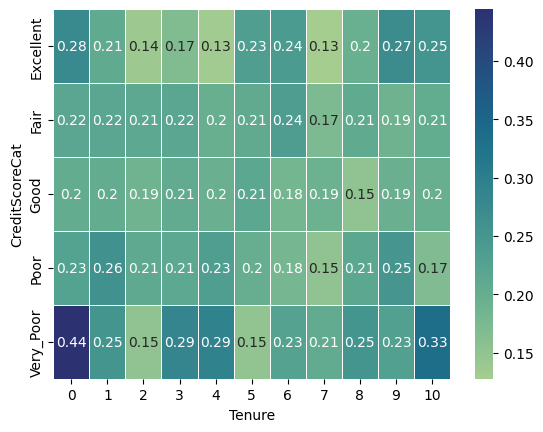

In [11]:
#9.10 
# Переведите числовой признак CreditScore в категориальный
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
    
#Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

#Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), 
#а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). 
#В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.
table=pd.pivot_table(churn_data, 
                     values='Exited', 
                     index='CreditScoreCat',
                     columns='Tenure',
                     aggfunc='mean')

#На основе полученной сводной таблицы постройте тепловую карту с аннотацией. 
# Найдите на тепловой карте категории клиентов, которые уходят чаще всего.
heatmap = sns.heatmap(
    table,
    annot = True,
    linewidth=.5,
    cmap="crest"
)

#Выводы: Клиенты с низким кредитным рейтингом и длительностью менее года наиболее подвержены уходу. 
# Также стоит обратить внимание на следующую группу по вероятности ухода: клиенты с низким кредитным рейтингом и длительностью более 10 лет.
# Третья группа риска, которую стоит выделить: новые клиенты (до года) с наилучшим кредитным рейтигом.